# Sprintlab LIS — Diagnosis & Signal Feasibility Audit
### Companion notebook to the literature review *"How to find the problem itself (diagnosis) — what are the signals?"* (Framework §4–6)

**Purpose.** The literature review asks whether each behavioural signal asserted in Master-Framework
Sections 4 (Cognitive Skills), 5 (Exam Skills) and 6 (Psychological & Behavioural Patterns) is
(a) grounded in psychology and (b) *actually measurable*. This notebook answers **(b)** against the real
proxy dataset (**XES3G5M**, processed into `sprintlabfiles/`).

For every one of the 12 constructs it delivers three things:
1. the **literature-grounded operational signal** (the formula the framework relies on),
2. a **Computable / Proxy-only / Not-computable** verdict on XES3G5M, and
3. a **worked demonstration** for every signal that *is* computable.

> **Bounded scope.** XES3G5M is a *proxy only* (Chinese K-12 **math**, knowledge-tracing logs).
> The target is Arabic school **science** (physics/chemistry/biology), Grades 7–12, inside a competitive
> multiplayer game. Findings here bound what the proxy can and cannot validate — not the target game.

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': .3, 'axes.spanselector': False} if False else
                    {'figure.dpi': 110, 'font.size': 11, 'axes.grid': True, 'grid.alpha': .3})
BLUE, RED, GREY = '#2b6cb0', '#c53030', '#718096'

# locate the processed proxy files whether run from notebooks/ or repo root
CANDIDATES = ['../sprintlabfiles', 'sprintlabfiles', '/home/abdulrahman/Desktop/Noxed/sprintlabfiles']
DATA_DIR = next(p for p in CANDIDATES if os.path.exists(os.path.join(p, 'responses.csv')))
FIG_DIR = os.path.join(os.path.dirname(DATA_DIR.rstrip('/')) if DATA_DIR.startswith('..') else '.',
                       'notebooks', 'outputs', 'figures')
FIG_DIR = '../notebooks/outputs/figures' if os.path.isdir('../notebooks') else 'outputs/figures'
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_DIR =', DATA_DIR)
print('FIG_DIR  =', FIG_DIR)

DATA_DIR = ../sprintlabfiles
FIG_DIR  = ../notebooks/outputs/figures


## 1. Load the proxy logs

`responses.csv` is the exploded per-response log: one row = one student answering one question.

In [2]:
resp = pd.read_csv(os.path.join(DATA_DIR, 'responses.csv'))
print('responses.csv:', f'{len(resp):,} rows')
print('students (uid):', f'{resp.uid.nunique():,}',
      '| questions:', f'{resp.questions.nunique():,}',
      '| concepts:', f'{resp.concepts.nunique():,}')
print('overall accuracy:', round(resp.responses.mean(), 3))
resp.head(4)

responses.csv: 5,139,044 rows
students (uid): 14,453 | questions: 7,618 | concepts: 865
overall accuracy: 0.796


,fold,uid,questions,concepts,responses,timestamps
0,0,11066,3751,187,1,1595229836000
1,0,11066,3752,187,1,1595233013000
2,0,11066,3753,374,1,1595233687000
3,0,11066,3754,187,0,1595236010000


## 2. Headline data finding — the timing granularity audit

**Almost every signal in Framework §4–6 is timing-based**: impulsiveness (`<30 % of theoretical
time`), stress (`>150 % of the student's own pace`), processing speed (`RT near the max even when
correct`), time management (`timeout rate`, `90 % of time on an easy item`), reading traps
(`fast-vs-slow before the trap distractor`). All of these need a trustworthy **per-item response
latency**.

Below we test whether XES3G5M's `timestamps` column *is* a per-item latency, or only a
session/submission timestamp.

In [3]:
r = resp.sort_values(['uid', 'timestamps']).reset_index(drop=True)
r['dt'] = r.groupby('uid')['timestamps'].diff() / 1000.0          # seconds between consecutive answers
r['bucket_size'] = r.groupby(['uid', 'timestamps'])['responses'].transform('size')

share_shared   = (r['bucket_size'] > 1).mean()                    # answers sharing a timestamp
share_dt0      = (r['dt'] == 0).mean()                            # consecutive answers with identical ts
q = {p: round(float(r['dt'].dropna().quantile(p)), 1) for p in (.1, .25, .5, .75, .9)}

print(f"Share of responses sharing a timestamp with another response : {share_shared:.1%}")
print(f"Share of consecutive answers with delta == 0 (identical ts)   : {share_dt0:.1%}")
print(f"Inter-response delta (s) quantiles                            : {q}")
print()
verdict = ("NOT a per-item latency -> timestamps are session/batch-level"
           if share_shared > 0.4 else "usable as per-item latency")
print("VERDICT:", verdict)

Share of responses sharing a timestamp with another response : 78.7%
Share of consecutive answers with delta == 0 (identical ts)   : 57.9%
Inter-response delta (s) quantiles                            : {0.1: 0.0, 0.25: 0.0, 0.5: 0.0, 0.75: 665.0, 0.9: 63711.0}

VERDICT: NOT a per-item latency -> timestamps are session/batch-level


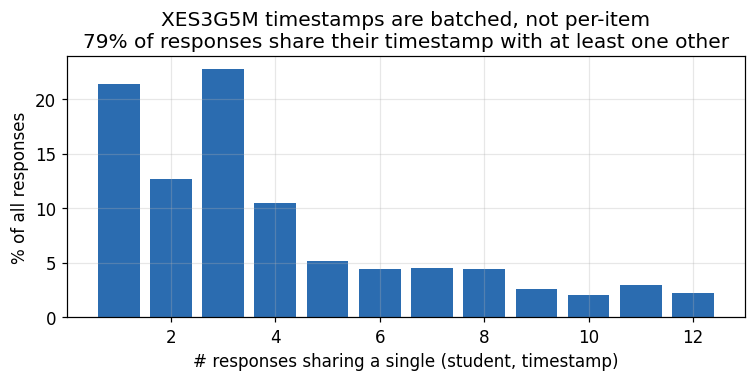

In [4]:
# Visualise the batching: distribution of how many answers share one timestamp
bs = r['bucket_size'].value_counts().sort_index()
bs = bs[bs.index <= 12]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(bs.index.astype(int), bs.values / len(r) * 100, color=BLUE)
ax.set_xlabel('# responses sharing a single (student, timestamp)')
ax.set_ylabel('% of all responses')
ax.set_title('XES3G5M timestamps are batched, not per-item\n'
             f'{share_shared:.0%} of responses share their timestamp with at least one other')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'timestamp_granularity.png'), bbox_inches='tight')
plt.show()

**Consequence.** Because ~79 % of responses share their timestamp and the median inter-response
gap is 0 s, XES3G5M **cannot** yield a per-item solving time. **Every timing-based signal in §4–6 is
therefore un-testable on the proxy** and depends entirely on Sprintlab instrumenting its own per-item
latency. This is the single most important instrumentation requirement the review surfaces.

## 3. Signal feasibility catalog — all 12 constructs

For each construct: the framework's proposed signal, the data it requires, and whether XES3G5M can
compute it. Verdicts:
`COMPUTABLE` (demonstrated below) · `PROXY-ONLY` (weak analog only) · `NEEDS LATENCY` ·
`NEEDS TAGS` (offline LLM distractor labels) · `NEEDS MULTI-SUBJECT` · `NEEDS GAME EVENTS`.

In [5]:
catalog = pd.DataFrame([
 # sec, construct, framework signal (short), required data, verdict
 ("4", "Working Memory",        "collapse on high cognitive-load items only",        "per-item load index + accuracy", "PROXY-ONLY"),
 ("4", "Processing Speed",      "accurate but RT near max on timed items",           "per-item latency + time-pressure tag", "NEEDS LATENCY"),
 ("4", "Sustained Attention",   "accuracy decay over last items of a match",         "within-session position + accuracy", "COMPUTABLE"),
 ("4", "Selective Attention",   "errors when a visual distractor is on the tile",    "in-game distractor events", "NEEDS GAME EVENTS"),
 ("4", "Cognitive Flexibility", "accuracy/RT drop after a SUBJECT switch",           "multi-subject sequence", "NEEDS MULTI-SUBJECT"),
 ("5", "Question Interpretation","fast pick of the reading-trap distractor",         "distractor tags + latency", "NEEDS TAGS"),
 ("5", "Time Management",       "timeout rate; 90% of time on an easy item",         "per-item latency + timeout events", "NEEDS LATENCY"),
 ("5", "Reasoning",            "fails high-logical-step, low-variable items",        "logical-steps tag + accuracy", "PROXY-ONLY"),
 ("6", "Impulsiveness",         "trick-distractor picked in <30% of theo. time",    "trick/distractor tags + latency", "NEEDS TAGS"),
 ("6", "Stress & Overthinking", "post-trigger easy-item error or +150% RT",          "game-state events + latency", "NEEDS GAME EVENTS"),
 ("6", "Low Self-Efficacy",     "final answer switched AWAY from correct",           "answer-change events", "NEEDS GAME EVENTS"),
 ("6", "Low Effort/Motivation", "flat-fast RT regardless of difficulty",             "per-item latency + engagement", "NEEDS LATENCY"),
 ("6", "Low Frustration (Tilt)","no recovery on item after a negative event",        "game-event log + accuracy", "NEEDS GAME EVENTS"),
], columns=["§", "Construct", "Framework signal", "Required data", "XES3G5M verdict"])

order = {"COMPUTABLE":0, "PROXY-ONLY":1, "NEEDS LATENCY":2, "NEEDS TAGS":3,
         "NEEDS MULTI-SUBJECT":4, "NEEDS GAME EVENTS":5}
summary = catalog["XES3G5M verdict"].value_counts().rename_axis("verdict").reset_index(name="constructs")
print("Feasibility summary:")
print(summary.to_string(index=False))
print(f"\nDirectly computable on the proxy: "
      f"{(catalog['XES3G5M verdict'].isin(['COMPUTABLE','PROXY-ONLY'])).sum()} of 12 constructs.")
catalog

Feasibility summary:
            verdict  constructs
  NEEDS GAME EVENTS           4
      NEEDS LATENCY           3
         PROXY-ONLY           2
         NEEDS TAGS           2
         COMPUTABLE           1
NEEDS MULTI-SUBJECT           1

Directly computable on the proxy: 3 of 12 constructs.


,§,Construct,Framework signal,Required data,XES3G5M verdict
0,4,Working Memory,collapse on high cognitive-load items only,per-item load index + accuracy,PROXY-ONLY
1,4,Processing Speed,accurate but RT near max on timed items,per-item latency + time-pressure tag,NEEDS LATENCY
2,4,Sustained Attention,accuracy decay over last items of a match,within-session position + accuracy,COMPUTABLE
3,4,Selective Attention,errors when a visual distractor is on the tile,in-game distractor events,NEEDS GAME EVENTS
4,4,Cognitive Flexibility,accuracy/RT drop after a SUBJECT switch,multi-subject sequence,NEEDS MULTI-SUBJECT
5,5,Question Interpretation,fast pick of the reading-trap distractor,distractor tags + latency,NEEDS TAGS
6,5,Time Management,timeout rate; 90% of time on an easy item,per-item latency + timeout events,NEEDS LATENCY
7,5,Reasoning,"fails high-logical-step, low-variable items",logical-steps tag + accuracy,PROXY-ONLY
8,6,Impulsiveness,trick-distractor picked in <30% of theo. time,trick/distractor tags + latency,NEEDS TAGS
9,6,Stress & Overthinking,post-trigger easy-item error or +150% RT,game-state events + latency,NEEDS GAME EVENTS


## 4. Demonstrations of the computable / proxy-only signals

The three signals the proxy can speak to are all **accuracy/sequence-based** (they need no latency):
sustained attention (§4.3), cognitive flexibility's switch penalty (§4.4), and a cognitive-load proxy
for working memory / reasoning (§4.1, §5.3). We build sessions first.

In [6]:
# Session = a run of one student's answers with < 30 min gaps (proxy for a 'match')
GAP_S = 1800
r['new_sess'] = r['dt'].isna() | (r['dt'] > GAP_S)
r['sess'] = r.groupby('uid')['new_sess'].cumsum()
r['pos'] = r.groupby(['uid', 'sess']).cumcount() + 1
sess_len = r.groupby(['uid', 'sess']).size()
print(f"sessions: {len(sess_len):,} | median length: {int(sess_len.median())} "
      f"| share with >=10 items: {(sess_len>=10).mean():.1%}")

sessions: 902,863 | median length: 3 | share with >=10 items: 18.1%


### 4a. Sustained attention (§4.3) — `COMPUTABLE`
Framework claim: accuracy should decay across a match as attention fatigues. We take sessions of ≥10
items and plot accuracy by within-session position.

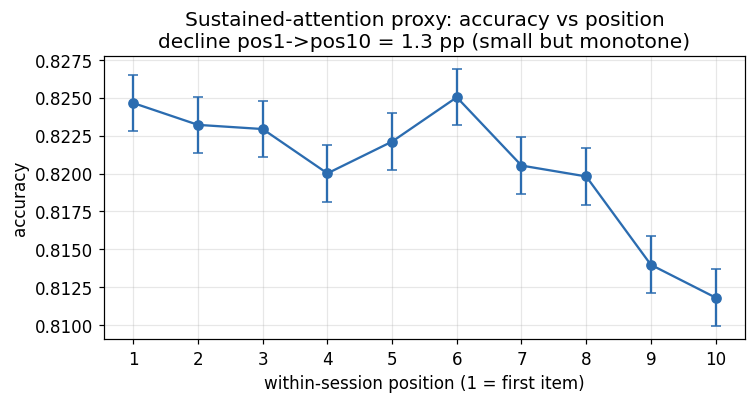

accuracy by position: {1: 0.825, 2: 0.823, 3: 0.823, 4: 0.82, 5: 0.822, 6: 0.825, 7: 0.821, 8: 0.82, 9: 0.814, 10: 0.812}

VERDICT: signal is DETECTABLE but WEAK (1.3 pp). XES3G5M is untimed & non-competitive, so true in-game fatigue is expected to be stronger — needs target data.


In [7]:
big = r[r.groupby(['uid', 'sess'])['pos'].transform('max') >= 10]
acc_pos = big[big.pos <= 10].groupby('pos')['responses'].mean()
n_pos   = big[big.pos <= 10].groupby('pos')['responses'].size()
se = np.sqrt(acc_pos * (1 - acc_pos) / n_pos)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(acc_pos.index, acc_pos.values, yerr=1.96 * se.values, marker='o', color=BLUE, capsize=3)
ax.set_xlabel('within-session position (1 = first item)')
ax.set_ylabel('accuracy'); ax.set_xticks(range(1, 11))
drop = acc_pos.iloc[0] - acc_pos.iloc[-1]
ax.set_title(f'Sustained-attention proxy: accuracy vs position\n'
             f'decline pos1->pos10 = {drop*100:.1f} pp (small but monotone)')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'sustained_attention.png'), bbox_inches='tight')
plt.show()
print("accuracy by position:", {int(k): round(v, 3) for k, v in acc_pos.items()})
print(f"\nVERDICT: signal is DETECTABLE but WEAK ({drop*100:.1f} pp). XES3G5M is untimed & "
      "non-competitive, so true in-game fatigue is expected to be stronger — needs target data.")

### 4b. Cognitive flexibility (§4.4) — `NEEDS MULTI-SUBJECT`
Framework claim: a subject switch (chemistry→physics) costs accuracy. XES3G5M is single-domain math,
so we can only test a *concept* switch — a much weaker analog. We expect ≈0, and that null is itself
the finding: the proxy cannot validate this construct.

In [8]:
r['prev_concept'] = r.groupby(['uid', 'sess'])['concepts'].shift()
r['switch'] = (r['concepts'] != r['prev_concept']) & r['prev_concept'].notna()
same_acc = r.loc[r.prev_concept.notna() & ~r.switch, 'responses'].mean()
sw_acc   = r.loc[r.switch, 'responses'].mean()
print(f"accuracy | same concept as previous : {same_acc:.3f}")
print(f"accuracy | different concept         : {sw_acc:.3f}")
print(f"concept-switch penalty               : {(same_acc - sw_acc)*100:+.2f} pp")
print("\nVERDICT: NEEDS MULTI-SUBJECT. Within a single subject the switch penalty is ~0; "
      "the framework's construct (physics<->chemistry<->biology) cannot be tested on this proxy.")

accuracy | same concept as previous : 0.803
accuracy | different concept         : 0.801
concept-switch penalty               : +0.22 pp

VERDICT: NEEDS MULTI-SUBJECT. Within a single subject the switch penalty is ~0; the framework's construct (physics<->chemistry<->biology) cannot be tested on this proxy.


### 4c. Cognitive-load proxy for Working Memory / Reasoning (§4.1, §5.3) — `PROXY-ONLY`
The framework separates **Variables_Count** (working-memory load) from **Logical_Steps** (reasoning
load). Neither tag exists in XES3G5M, so we build crude proxies from `question_metadata`:
number of KCs per question (breadth ≈ variables) and solution-explanation length (steps ≈ reasoning).

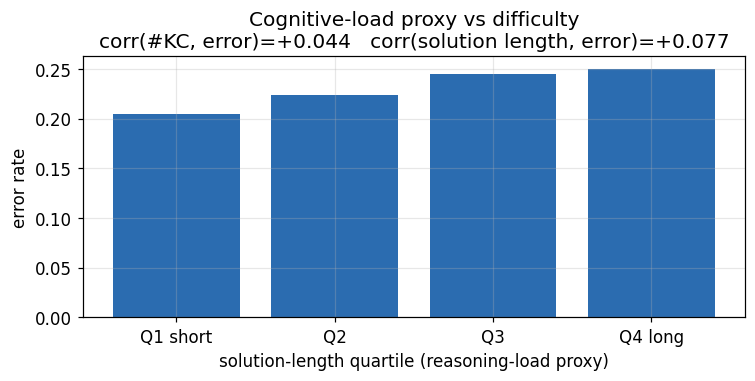

error rate by reasoning-load quartile: {'Q1 short': 0.205, 'Q2': 0.223, 'Q3': 0.245, 'Q4 long': 0.25}

VERDICT: PROXY-ONLY. A weak positive load->difficulty trend exists, but without the true Variables_Count / Logical_Steps tags the working-memory vs reasoning split (§4.5) is untestable.


In [9]:
qm = pd.read_csv(os.path.join(DATA_DIR, 'question_metadata.csv'),
                 usecols=['index', 'kc_ids', 'analysis', 'error_rate', 'attempted'])
def n_kc(s):
    s = str(s).strip()
    return 0 if s in ('', 'nan', '[]', '{}') else s.count(',') + 1
qm['n_kc'] = qm['kc_ids'].apply(n_kc)
qm['analysis_len'] = qm['analysis'].fillna('').astype(str).str.len()
qm = qm[qm['attempted'] >= 30]                                   # stable error rates only

c1 = qm[['n_kc', 'error_rate']].corr().iloc[0, 1]
c2 = qm[['analysis_len', 'error_rate']].corr().iloc[0, 1]
qm['load_q'] = pd.qcut(qm['analysis_len'], 4, labels=['Q1 short', 'Q2', 'Q3', 'Q4 long'])
by_load = qm.groupby('load_q', observed=True)['error_rate'].mean()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(range(len(by_load)), by_load.values, color=BLUE)
ax.set_xticks(range(len(by_load))); ax.set_xticklabels(by_load.index)
ax.set_xlabel('solution-length quartile (reasoning-load proxy)'); ax.set_ylabel('error rate')
ax.set_title(f'Cognitive-load proxy vs difficulty\n'
             f'corr(#KC, error)={c1:+.3f}   corr(solution length, error)={c2:+.3f}')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'cognitive_load_proxy.png'), bbox_inches='tight')
plt.show()
print("error rate by reasoning-load quartile:", {k: round(v, 3) for k, v in by_load.items()})
print("\nVERDICT: PROXY-ONLY. A weak positive load->difficulty trend exists, but without the true "
      "Variables_Count / Logical_Steps tags the working-memory vs reasoning split (§4.5) is untestable.")

### 4d. Practice / learning effect (context) — already established
Not a §4–6 diagnosis, but it confirms the proxy *does* carry clean learning signal (accuracy improves
with KC exposure), which is why timing — not learning — is the specific gap for behavioural diagnosis.

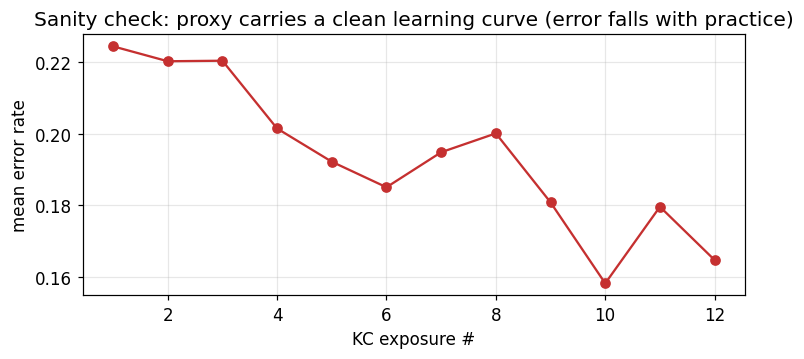

mean error by exposure 1..12: [np.float64(0.224), np.float64(0.22), np.float64(0.22), np.float64(0.202), np.float64(0.192), np.float64(0.185), np.float64(0.195), np.float64(0.2), np.float64(0.181), np.float64(0.158), np.float64(0.18), np.float64(0.165)]


In [10]:
pe = pd.read_csv(os.path.join(DATA_DIR, 'practice_effect_perKC.csv'))
expo = [c for c in pe.columns if c.startswith('exposure_')][:12]
curve = pe[expo].mean()                                          # mean error rate per exposure #
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(curve) + 1), curve.values, marker='o', color=RED)
ax.set_xlabel('KC exposure #'); ax.set_ylabel('mean error rate')
ax.set_title('Sanity check: proxy carries a clean learning curve (error falls with practice)')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'practice_effect.png'), bbox_inches='tight')
plt.show()
print("mean error by exposure 1..12:", [round(v, 3) for v in curve.values])

## 5. Instrumentation requirements — what Sprintlab must log

The audit converts directly into an engineering spec. For 10 of 12 constructs the blocker is **data
Sprintlab does not yet capture**, not the diagnostic logic. Ranked by how many constructs each unlocks:

In [11]:
req = pd.DataFrame([
 ("Per-item response latency (ms, per student per question)", "Processing Speed, Time Management, Low Effort, Impulsiveness, Stress, Reading (6+)"),
 ("Chosen-option + offline LLM distractor tags (A-Tags)",     "Impulsiveness, Reading traps, Misconception attribution (3)"),
 ("In-game event log (triggers, attacks, distractor tiles)",  "Selective Attention, Stress, Tilt (3)"),
 ("Answer-change events (initial vs final selection)",        "Low Self-Efficacy (1)"),
 ("Per-item Variables_Count & Logical_Steps tags",            "Working Memory, Reasoning, WM-vs-Reasoning split (3)"),
 ("Multi-subject interleaving in the session stream",         "Cognitive Flexibility (1)"),
], columns=["Instrumentation Sprintlab must add", "Constructs it unlocks"])
req

,Instrumentation Sprintlab must add,Constructs it unlocks
0,"Per-item response latency (ms, per student per...","Processing Speed, Time Management, Low Effort,..."
1,Chosen-option + offline LLM distractor tags (A...,"Impulsiveness, Reading traps, Misconception at..."
2,"In-game event log (triggers, attacks, distract...","Selective Attention, Stress, Tilt (3)"
3,Answer-change events (initial vs final selection),Low Self-Efficacy (1)
4,Per-item Variables_Count & Logical_Steps tags,"Working Memory, Reasoning, WM-vs-Reasoning spl..."
5,Multi-subject interleaving in the session stream,Cognitive Flexibility (1)


## 6. Conclusion

- **2 of 12** §4–6 constructs are even *weakly* observable in XES3G5M (sustained attention; a
  cognitive-load-vs-difficulty trend). Both are accuracy/sequence-based.
- **10 of 12** are **not testable on the proxy** — blocked by missing per-item latency (the dominant
  gap), missing distractor/load tags, missing in-game event logs, or the single-subject domain.
- The proxy is excellent for **content/knowledge-tracing** signal (clean learning & differentiation
  curves) but is structurally silent on **behavioural** diagnosis, which is exactly the §4–6 target.
- **Therefore:** the literature review's behavioural signals cannot be validated on borrowed KT data.
  They require Sprintlab's own instrumentation — headed by **per-item response latency** — after which
  the framework's timing thresholds must be re-calibrated per student (PPF, §7.1) and per grade band
  (§7.2) before any diagnosis is trusted.